In [87]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Dropout,
    Bidirectional, LSTM, Dense,
    GlobalAveragePooling1D, Multiply, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Lambda
import os

DATA_DIR  = "../data"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Imports OK")
print(f"TensorFlow version: {tf.__version__}")


Imports OK
TensorFlow version: 2.21.0


In [88]:
X_train = np.load(f"{DATA_DIR}/X_train.npy")
X_val   = np.load(f"{DATA_DIR}/X_val.npy")
X_test  = np.load(f"{DATA_DIR}/X_test.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

print(f"X_train : {X_train.shape}  |  Leaks = {y_train.sum()}")
print(f"X_val   : {X_val.shape}  |  Leaks = {y_val.sum()}")
print(f"X_test  : {X_test.shape}  |  Leaks = {y_test.sum()}")

WINDOW_SIZE = X_train.shape[1]   # 20
N_FEATURES  = X_train.shape[2]   # 6
print(f"\nWindow size : {WINDOW_SIZE}")
print(f"N features  : {N_FEATURES}")


X_train : (111, 20, 6)  |  Leaks = 37
X_val   : (23, 20, 6)  |  Leaks = 7
X_test  : (30, 20, 6)  |  Leaks = 8

Window size : 20
N features  : 6


In [89]:
def focal_loss(gamma=2.0, alpha=0.6):
    def loss_fn(y_true, y_pred):
        y_pred  = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
        return K.mean(-alpha_t * K.pow(1.0 - p_t, gamma) * K.log(p_t))
    loss_fn.__name__ = 'focal_loss'
    return loss_fn

print("Focal Loss defined")
print("   gamma = 2.0  -> focuses on hard misclassified samples")
print("   alpha = 0.6  -> moderate upweighting for Leak class")


Focal Loss defined
   gamma = 2.0  -> focuses on hard misclassified samples
   alpha = 0.6  -> moderate upweighting for Leak class


In [90]:
from tensorflow.keras.layers import Softmax
from tensorflow.keras import regularizers

def build_model(window_size, n_features):
    inp = Input(shape=(window_size, n_features), name='input')

    # Small model for small dataset size to reduce overfitting
    x = Conv1D(
        16, kernel_size=3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(1e-4), name='conv1'
    )(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(0.3, name='drop1')(x)

    x = Bidirectional(
        LSTM(
            32, return_sequences=True,
            dropout=0.2, recurrent_dropout=0.2,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        name='bilstm'
    )(x)

    # Attention over timesteps (axis=1), avoids softmax-on-size-1 warning
    score  = Dense(1, activation='tanh', name='attn_score')(x)
    weight = Softmax(axis=1, name='attn_weight')(score)
    x      = Multiply(name='attn_context')([x, weight])
    x      = GlobalAveragePooling1D(name='gap')(x)

    x   = Dropout(0.5, name='drop2')(x)
    x   = Dense(
        16, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense1'
    )(x)
    out = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss=focal_loss(gamma=2.0, alpha=0.6),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc_roc', curve='ROC'),
            tf.keras.metrics.AUC(name='auc_pr', curve='PR')
        ]
    )
    return model

model = build_model(WINDOW_SIZE, N_FEATURES)
model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 20, 16)    │        304 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 20, 16)    │         64 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 20, 16)    │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 20, 64)    │     12,544 │ drop1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 20, 1)     │         65 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weight         │ (None, 20, 1)     │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, 20, 64)    │          0 │ bilstm[0][0],     │
│ (Multiply)          │                   │            │ attn_weight[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 64)        │          0 │ attn_context[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 64)        │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 16)        │      1,040 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,034 (54.82 KB)

 Trainable params: 14,002 (54.70 KB)

 Non-trainable params: 32 (128.00 B)

In [91]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

USE_CLASS_WEIGHT = False

print(f"Class weights: {class_weight}")
print(f"  Normal (0) weight : {class_weight[0]:.4f}")
print(f"  Leak   (1) weight : {class_weight[1]:.4f}")
print(f"Using class weights in fit: {USE_CLASS_WEIGHT}")
print("Recommendation: keep this False when focal loss is already used.")


Class weights: {np.int64(0): np.float64(0.75), np.int64(1): np.float64(1.5)}
  Normal (0) weight : 0.7500
  Leak   (1) weight : 1.5000
Using class weights in fit: False
Recommendation: keep this False when focal loss is already used.


In [92]:
callbacks = [
    EarlyStopping(
        monitor='val_auc_pr',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr',
        factor=0.5,
        patience=5,
        mode='max',
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{MODEL_DIR}/best_model.keras",
        monitor='val_auc_pr',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("Callbacks defined")
print("   EarlyStopping      -> patience=10, monitors val_auc_pr")
print("   ReduceLROnPlateau  -> halves LR if val_auc_pr stalls for 5 epochs")
print("   ModelCheckpoint    -> saves best model to models/best_model.keras")


Callbacks defined
   EarlyStopping      -> patience=10, monitors val_auc_pr
   ReduceLROnPlateau  -> halves LR if val_auc_pr stalls for 5 epochs
   ModelCheckpoint    -> saves best model to models/best_model.keras


In [93]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=8,
    class_weight=(class_weight if USE_CLASS_WEIGHT else None),
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining complete")
print(f"   Stopped at epoch : {len(history.history['loss'])}")
print(f"   Best val_auc_pr  : {max(history.history['val_auc_pr']):.4f}")
print(f"   Best val_auc_roc : {max(history.history['val_auc_roc']):.4f}")


Epoch 1/60
12/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6039 - auc_pr: 0.5045 - auc_roc: 0.5557 - loss: 0.0921
Epoch 1: val_auc_pr improved from None to 0.39220, saving model to ../models/best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5856 - auc_pr: 0.4570 - auc_roc: 0.5709 - loss: 0.0895 - val_accuracy: 0.6957 - val_auc_pr: 0.3922 - val_auc_roc: 0.6473 - val_loss: 0.0880 - learning_rate: 5.0000e-04
Epoch 2/60
10/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6897 - auc_pr: 0.2597 - auc_roc: 0.4593 - loss: 0.0864      
Epoch 2: val_auc_pr did not improve from 0.39220
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6486 - auc_pr: 0.3164 - auc_roc: 0.4730 - loss: 0.0890 - val_accuracy: 0.6957 - val_auc_pr: 0.3286 - val_auc_roc: 0.5446 - val_loss: 0.0876 - learning_rate: 5.0000e-04
Epoch 3/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6821 - auc_pr: 0.4691 - auc_roc: 0.6474 - loss: 0.0871
Epoch 3: val_auc_pr did not improve from 0.3922

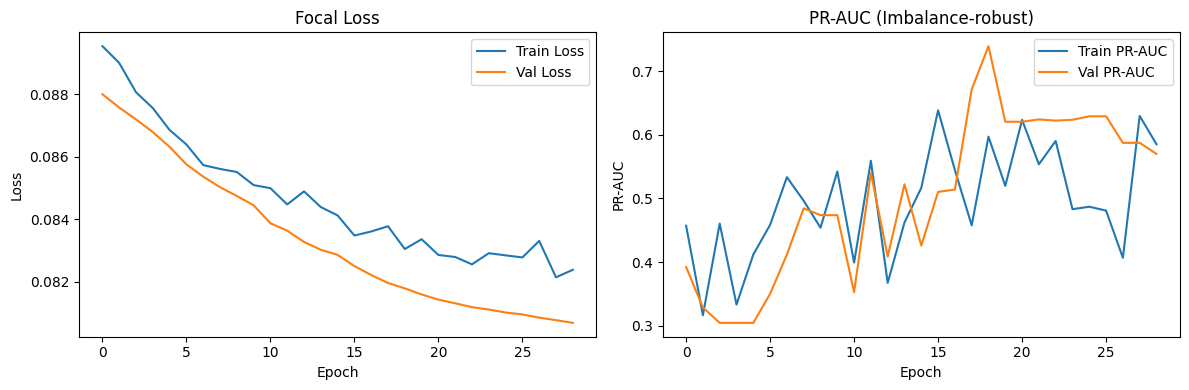

Saved -> paper/images/fig6_training_curves.png


In [94]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Focal Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['auc_pr'],     label='Train PR-AUC')
axes[1].plot(history.history['val_auc_pr'], label='Val PR-AUC')
axes[1].set_title('PR-AUC (Imbalance-robust)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig("../paper/images/fig6_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved -> paper/images/fig6_training_curves.png")


In [95]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, roc_auc_score

y_val_proba = model.predict(X_val, verbose=0).flatten()
y_test_proba = model.predict(X_test, verbose=0).flatten()

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

# thresholds has one fewer element than precision/recall
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
best_f1 = float(f1_scores[best_idx])

print(f"Best threshold (from val PR curve): {best_threshold:.4f}")
print(f"Best validation F1: {best_f1:.4f}")

def summarize_split(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    print(f"\n=== {name} @ threshold={threshold:.4f} ===")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1        : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Pred Leak%: {y_pred.mean()*100:.2f}%")

summarize_split('Validation', y_val, y_val_proba, best_threshold)
summarize_split('Test', y_test, y_test_proba, best_threshold)


Best threshold (from val PR curve): 0.4923
Best validation F1: 0.7273

=== Validation @ threshold=0.4923 ===
ROC-AUC   : 0.7946
Precision : 1.0000
Recall    : 0.5714
F1        : 0.7273
Pred Leak%: 17.39%

=== Test @ threshold=0.4923 ===
ROC-AUC   : 0.7216
Precision : 0.6000
Recall    : 0.3750
F1        : 0.4615
Pred Leak%: 16.67%


In [96]:
best_ep_pr = int(np.argmax(history.history['val_auc_pr'])) + 1
best_ep_roc = int(np.argmax(history.history['val_auc_roc'])) + 1

print("=== TRAINING SNAPSHOT ===")
print(f"Epochs run          : {len(history.history['loss'])}")
print(f"Best val PR-AUC     : {max(history.history['val_auc_pr']):.4f} (epoch {best_ep_pr})")
print(f"Best val ROC-AUC    : {max(history.history['val_auc_roc']):.4f} (epoch {best_ep_roc})")
print(f"Final train PR-AUC  : {history.history['auc_pr'][-1]:.4f}")
print(f"Final val PR-AUC    : {history.history['val_auc_pr'][-1]:.4f}")
print(f"Final train loss    : {history.history['loss'][-1]:.4f}")
print(f"Final val loss      : {history.history['val_loss'][-1]:.4f}")


=== TRAINING SNAPSHOT ===
Epochs run          : 29
Best val PR-AUC     : 0.7393 (epoch 19)
Best val ROC-AUC    : 0.7991 (epoch 18)
Final train PR-AUC  : 0.5851
Final val PR-AUC    : 0.5700
Final train loss    : 0.0824
Final val loss      : 0.0807
